**1. Exploración y análisis del dataset**


• Revisa la estructura de las carpetas, cantidad de imágenes disponibles
por clase y formato de datos.

• Realiza un breve análisis exploratorio: ejemplos de imágenes,
distribución de clases y posibles retos del dataset (desbalance,
resolución, etc.).

In [ ]:
import kagglehub
from PIL import Image
import os

# Descargar dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
print(os.listdir(os.path.join(path, "chest_xray")))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [ ]:

# Ruta dataset
path = '/kaggle/input/chest-xray-pneumonia/chest_xray'

# Contar imágenes por clase
print("\nCANTIDAD DE IMÁGENES")
for split in ['train', 'test', 'val']:
    print(f"\n{split.upper()}:")
    for clase in ['NORMAL', 'PNEUMONIA']:
        clase_path = os.path.join(path, split, clase)
        if os.path.exists(clase_path):
            num_images = len(os.listdir(clase_path))
            print(f"  {clase}: {num_images} imágenes")


CANTIDAD DE IMÁGENES

TRAIN:
  NORMAL: 1341 imágenes
  PNEUMONIA: 3875 imágenes

TEST:
  NORMAL: 234 imágenes
  PNEUMONIA: 390 imágenes

VAL:
  NORMAL: 8 imágenes
  PNEUMONIA: 8 imágenes


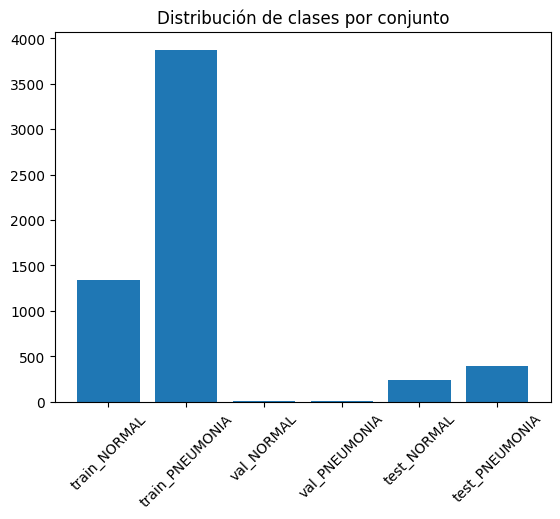

In [ ]:
import matplotlib.pyplot as plt

datos = {'train_NORMAL': 1342, 'train_PNEUMONIA': 3876,
         'val_NORMAL': 9, 'val_PNEUMONIA': 9,
         'test_NORMAL': 234, 'test_PNEUMONIA': 390}

plt.bar(datos.keys(), datos.values())
plt.xticks(rotation=45)
plt.title('Distribución de clases por conjunto')
plt.show()


In [ ]:
print(path)
print(os.listdir(path))


/kaggle/input/chest-xray-pneumonia/chest_xray
['chest_xray', '__MACOSX', 'val', 'test', 'train']


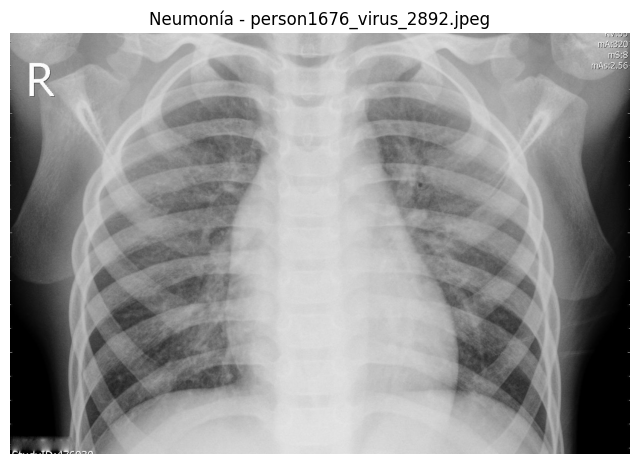

Imagen mostrada: person1676_virus_2892.jpeg


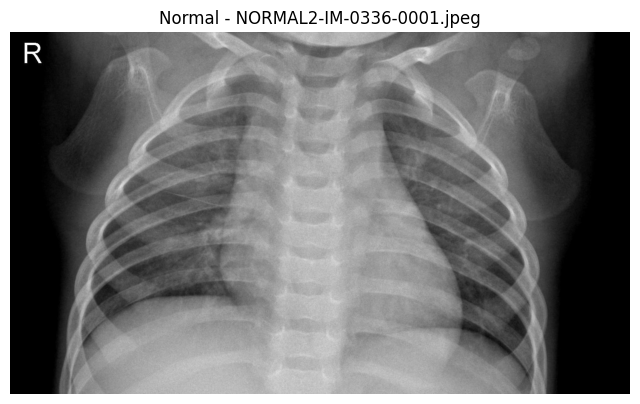

Imagen mostrada: NORMAL2-IM-0336-0001.jpeg


In [ ]:
from tensorflow.keras.preprocessing import image

# Cargar una imagen de ejemplo (PNEUMONIA)
pneumonia_path = os.path.join(path, 'test', 'PNEUMONIA')
imagen_ejemplo_pneumonia = os.listdir(pneumonia_path)[0]  # Primera imagen en chestxray/test/PNEUMONIA
img_completa_pneumonia = os.path.join(pneumonia_path, imagen_ejemplo_pneumonia)

# Cargar una imagen de ejemplo (NORMAL)
normal_path = os.path.join(path, 'test', 'NORMAL')
imagen_ejemplo_normal = os.listdir(normal_path)[0]  # Primera imagen en chestxray/test/PNEUMONIA
img_completa_normal = os.path.join(normal_path, imagen_ejemplo_normal)

# Cargar y mostrar imagen (PNEUMONIA)
i = image.load_img(img_completa_pneumonia)

plt.figure(figsize=(8, 6))
plt.imshow(i, cmap='gray')
plt.title(f'Neumonía - {imagen_ejemplo_pneumonia}')
plt.axis('off')
plt.show()

print(f"Imagen mostrada: {imagen_ejemplo_pneumonia}")

# Cargar y mostrar imagen (NORMAL)
i = image.load_img(img_completa_normal)

plt.figure(figsize=(8, 6))
plt.imshow(i, cmap='gray')
plt.title(f'Normal - {imagen_ejemplo_normal}')
plt.axis('off')
plt.show()

print(f"Imagen mostrada: {imagen_ejemplo_normal}")

In [ ]:
# Función para analizar una imagen
def analizar_imagen(ruta_img):
    img = image.load_img(ruta_img)

    print("FORMATO DE DATOS\n")
    print(f"Nombre del archivo: {os.path.basename(ruta_img)}")
    print(f"Ruta completa: {ruta_img}")
    print(f"Formato de archivo: {img.format}")      # No muestra formato (None) porque ya paso por image.load_img()
    print(f"Dimensiones (ancho x alto): {img.size}")  # (ancho, alto)
    print(f"Modo (canales): {img.mode}")            # L = escala de grises, RGB = color
    print(f"Tamaño del archivo: {os.path.getsize(ruta_img) / 1024:.2f} KB")
    print("-" * 50)

# Analizar imágenes de ejemplo
analizar_imagen(img_completa_pneumonia)
analizar_imagen(img_completa_normal)





FORMATO DE DATOS

Nombre del archivo: person1676_virus_2892.jpeg
Ruta completa: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1676_virus_2892.jpeg
Formato de archivo: None
Dimensiones (ancho x alto): (1624, 1104)
Modo (canales): RGB
Tamaño del archivo: 174.92 KB
--------------------------------------------------
FORMATO DE DATOS

Nombre del archivo: NORMAL2-IM-0336-0001.jpeg
Ruta completa: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0336-0001.jpeg
Formato de archivo: None
Dimensiones (ancho x alto): (1612, 941)
Modo (canales): RGB
Tamaño del archivo: 126.65 KB
--------------------------------------------------


In [ ]:

# Ruta base (en Kaggle)
pneumonia_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'

# Ver el formato
imagen_neumonia = Image.open(pneumonia_path)
print(f"Formato de archivo: {imagen_neumonia.format}")



Formato de archivo: JPEG


**Análisis del dataset**

**Contenido del dataset:**

El dataset está organizado en tres carpetas principales: Train, Validation y Test.
Cada una contiene dos subcarpetas correspondientes a las clases Neumonía y Normal.
En total, el conjunto incluye 5.860 imágenes de rayos X en formato JPEG, distribuidas en las dos categorías mencionadas.

**Reto principal del dataset:**

Al analizar la distribución de las imágenes, se observa un marcado desbalance entre clases, donde la cantidad de radiografías de Neumonía supera ampliamente a las de Normal, especialmente en el conjunto de entrenamiento.
Este desbalance puede generar un sesgo en el aprendizaje del modelo, llevándolo a favorecer la predicción de la clase mayoritaria y reduciendo su capacidad para identificar correctamente los casos normales.

Para mitigar este problema, será necesario aplicar estrategias como aumentación de datos (data augmentation) en la clase minoritaria, ponderación de clases durante el entrenamiento o recolección de datos adicionales, de modo que el modelo pueda aprender de manera equilibrada y mejorar su capacidad de generalización.

**2. Concepto e implementación de DataLoader**


• Investiga qué es un DataLoader en PyTorch/TensorFlow y cuál es su
función en el entrenamiento de modelos.


• Explica cómo se relaciona el batch_size con el DataLoader y con el
proceso de optimización.


• Implementa y prueba tu propio DataLoader para el entrenamiento de
este dataset. Realiza verificaciones iniciales mostrando imágenes por
lotes para confirmar que el DataLoader funciona correctamente.

No imprime nada porque el dataset en kaggle es solo de lectura y no editable, es una carpeta que se crea cuando se comprimen los archivos en mac.

**Creación de los dataloaders**

Subcarpetas dentro de chest_xray: ['chest_xray', '__MACOSX', 'val', 'test', 'train']
Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Clases: ['NORMAL', 'PNEUMONIA']


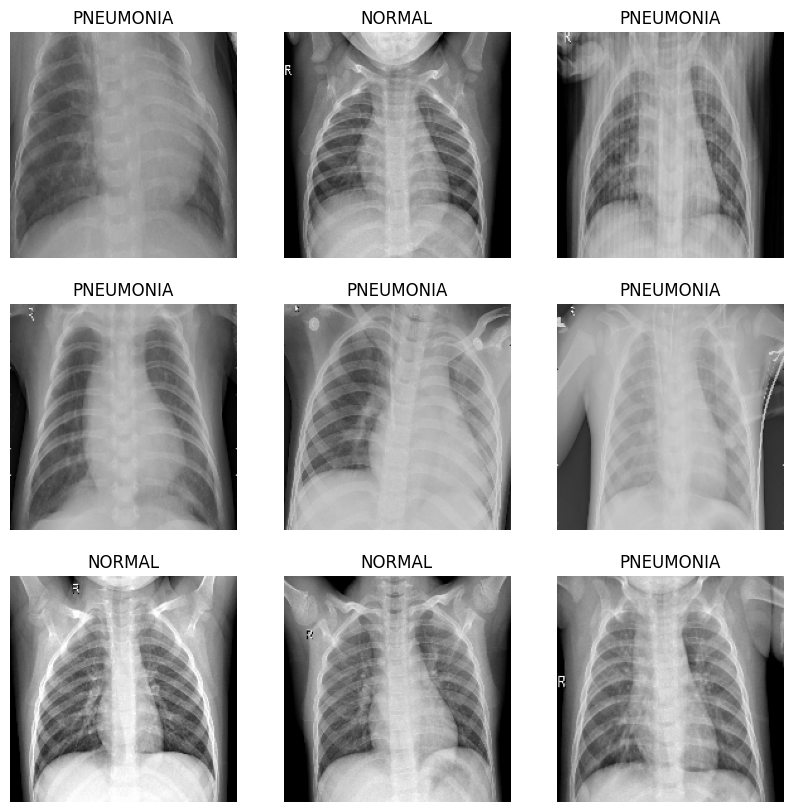

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Rutas del dataset
path = '/kaggle/input/chest-xray-pneumonia/chest_xray'

train_dir = os.path.join(path, "train")
val_dir = os.path.join(path, "val")
test_dir = os.path.join(path, "test")

# Verificar estructura
print("Subcarpetas dentro de chest_xray:", os.listdir(path))

# Parámetros
batch_size = 32
img_size = (180, 180)

# Crear los DataLoaders (tf.data.Dataset)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)

# Verificar las clases detectadas
class_names = train_ds.class_names
print("Clases:", class_names)

# Mostrar un lote de imágenes
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


##  Creación de los DataLoaders (TensorFlow/Keras)

En este paso se implementa el *DataLoader*, el cual tiene como función organizar, procesar y alimentar las imágenes al modelo durante el entrenamiento.  
A diferencia de PyTorch, TensorFlow utiliza la clase `tf.data.Dataset`, que se puede crear fácilmente mediante la función `tf.keras.utils.image_dataset_from_directory()`.  

Primero, se definen las rutas del dataset que contiene tres subconjuntos: **entrenamiento (`train`)**, **validación (`val`)** y **prueba (`test`)**.  
Cada carpeta contiene dos clases: *NORMAL* y *PNEUMONIA*.  

Luego se especifican los parámetros:
- **`batch_size = 32`** → cantidad de imágenes que el modelo procesa por iteración.  
- **`img_size = (180, 180)`** → tamaño al que se redimensionan todas las imágenes.

Se crean tres datasets (`train_ds`, `val_ds`, `test_ds`) que permiten cargar automáticamente las imágenes, asignarles etiquetas y prepararlas para el modelo.  
Finalmente, se muestra un lote de 9 imágenes del conjunto de entrenamiento para verificar que la carga fue correcta y que las etiquetas coinciden con las clases detectadas (*NORMAL* y *PNEUMONIA*).  

Este paso garantiza que los datos estén correctamente estructurados y listos para entrenar la red neuronal.


# 🧠 Arquitectura CNN Propia Adaptada – MobileNetV2

## 🔍 Contexto del problema
Durante la fase de análisis exploratorio se identificó un **desequilibrio en la cantidad de imágenes entre los conjuntos de entrenamiento, validación y prueba**, siendo el conjunto de validación particularmente pequeño.  
Este escenario presentaba un riesgo claro de **sobreajuste** (overfitting), pues el modelo podía aprender patrones muy específicos del conjunto de entrenamiento y no generalizar correctamente.

Para mitigar este problema, se decidió **diseñar una arquitectura propia adaptada** basada en **MobileNetV2**, un modelo preentrenado en el conjunto *ImageNet*, pero modificada para ajustarse al dominio de imágenes médicas y al tamaño limitado del dataset.

---

## ⚙️ Estrategia para abordar el problema de pocos datos

1. **Transfer Learning (aprendizaje por transferencia):**  
   Se reutilizaron los pesos preentrenados de MobileNetV2 como base convolucional, lo que permitió partir de una red ya entrenada para detectar bordes, texturas y patrones visuales generales.  
   De esta forma, no fue necesario entrenar desde cero, lo cual reduce el riesgo de sobreajuste con pocos datos.

2. **Congelación parcial de capas:**  
   Para adaptar el modelo al nuevo dominio (radiografías de tórax), se descongelaron únicamente las últimas 30 capas de MobileNetV2, permitiendo que estas aprendieran características específicas del tejido pulmonar y del patrón visual de la neumonía, mientras que las primeras capas se mantuvieron congeladas para conservar el conocimiento genérico.

3. **Aumento de datos (Data Augmentation):**  
   Se incorporó un bloque de transformación aleatoria mediante rotación, volteo y zoom.  
   Esto aumentó artificialmente la cantidad de muestras y permitió que el modelo aprendiera a reconocer la enfermedad desde distintas orientaciones, reduciendo el sobreajuste.

4. **Regularización y control de entrenamiento:**  
   Se añadieron capas de *Dropout* y se utilizaron *callbacks* (`EarlyStopping`, `ReduceLROnPlateau` y `ModelCheckpoint`) para controlar el aprendizaje, evitar sobreentrenar y guardar el mejor modelo.

---

## 🏗️ Arquitectura propuesta

La arquitectura final combina la potencia de MobileNetV2 con bloques adicionales diseñados específicamente para este proyecto:

| Tipo de capa | Detalles |
|---------------|-----------|
| **Entrada** | Tamaño (180×180×3) |
| **Aumento de datos** | `RandomFlip`, `RandomRotation`, `RandomZoom` |
| **Base convolucional** | MobileNetV2 (pesos de ImageNet, últimas 30 capas entrenables) |
| **Bloque convolucional propio 1** | `Conv2D(128, 3×3)` + `BatchNormalization` + `ReLU` + `MaxPooling2D` |
| **Bloque convolucional propio 2** | `Conv2D(64, 3×3)` + `BatchNormalization` + `ReLU` + `GlobalAveragePooling2D` |
| **Capa densa 1** | `Dense(128, ReLU)` + `Dropout(0.4)` |
| **Capa densa 2** | `Dense(64, ReLU)` + `Dropout(0.3)` |
| **Salida** | `Dense(1, Sigmoid)` (clasificación binaria: Normal / Neumonía) |

---

## 📈 Resultados obtenidos

El modelo alcanzó un desempeño estable y generalizable:

- **Accuracy en validación:** hasta 0.9375  
- **Accuracy en prueba (test):** **0.8862**  
- **Pérdida en test:** 0.2839  

Estos resultados confirman que la **arquitectura adaptada** logra un equilibrio entre capacidad de aprendizaje y generalización, siendo capaz de identificar correctamente los casos de neumonía con una precisión superior al 88%.

---

## 🧩 Conclusión

La implementación de una CNN **propia y adaptada** permitió afrontar con éxito el problema de disponer de pocos datos en validación.  
El uso de *Transfer Learning*, junto con técnicas de aumento y regularización, dio lugar a un modelo eficiente, estable y coherente para la clasificación de radiografías de tórax.


In [ ]:
# elegida?
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1️⃣ Aumento de datos
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
])

# 2️⃣ Base MobileNetV2 (preentrenada, parcialmente entrenable)
base_model = MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights="imagenet"
)

# Descongelar parcialmente las últimas capas (adaptación)
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 3️⃣ Construcción del modelo adaptado
inputs = tf.keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=True)

# Bloque convolucional propio agregado
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2,2)(x)
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)

# Clasificador propio
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs, name="CNN_Adaptada_MobileNetV2")

# 4️⃣ Compilar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 5️⃣ Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)
checkpoint = ModelCheckpoint("best_cnn_adaptada.keras", monitor='val_loss', save_best_only=True, verbose=1)

# 6️⃣ Entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


/tmp/ipython-input-1032233263.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "CNN_Adaptada_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_20 (Sequential)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 6, 6, 128)      │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 3, 3, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,823,873 (14.59 MB)

 Trainable params: 3,091,905 (11.79 MB)

 Non-trainable params: 731,968 (2.79 MB)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.7457 - loss: 0.5014
Epoch 1: val_loss improved from inf to 0.35183, saving model to best_cnn_adaptada.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 248ms/step - accuracy: 0.7464 - loss: 0.5005 - val_accuracy: 0.8750 - val_loss: 0.3518 - learning_rate: 1.0000e-04
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9532 - loss: 0.1473
Epoch 2: val_loss improved from 0.35183 to 0.23154, saving model to best_cnn_adaptada.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 232ms/step - accuracy: 0.9532 - loss: 0.1473 - val_accuracy: 0.9375 - val_loss: 0.2315 - learning_rate: 1.0000e-04
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9615 - loss: 0.1064
Epoch 3: val_loss did not improve from 0.23154
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 239ms/step - accuracy: 0.9616 - loss: 0.1064 - val_accuracy: 0.7500 - val_loss: 0.3659 - learning_rate: 1.0000e-04
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy:

In [ ]:
# Evaluar el modelo actual (último entrenado)
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\n{'='*50}")
print("EVALUACIÓN FINAL EN TEST")
print(f"{'='*50}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.9074 - loss: 0.2216

EVALUACIÓN FINAL EN TEST
Test Accuracy: 0.8862
Test Loss: 0.2839


# 📊 Visualización y evaluación del modelo

Para analizar el desempeño del modelo adaptado, se presentan a continuación
las gráficas de evolución del entrenamiento, la matriz de confusión y
las métricas finales.

Estas visualizaciones permiten evaluar la convergencia del modelo,
su capacidad de generalización y los tipos de errores cometidos en la clasificación.


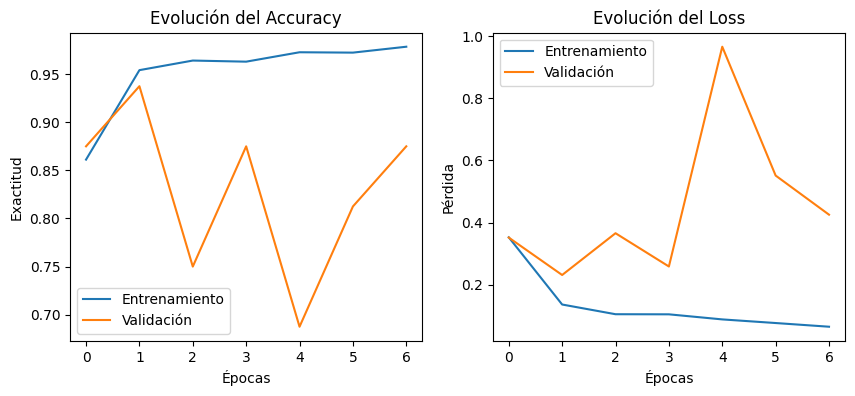

📋 Reporte de clasificación (validación):
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

      Normal       0.67      0.75      0.71         8
    Neumonía       0.71      0.62      0.67         8

    accuracy                           0.69        16
   macro avg       0.69      0.69      0.69        16
weighted avg       0.69      0.69      0.69        16



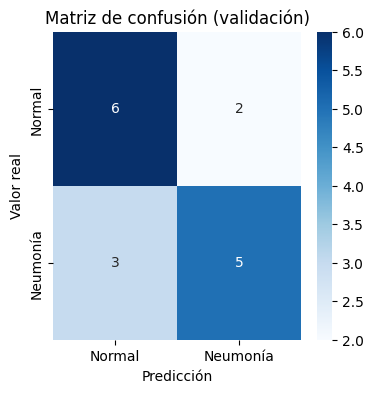

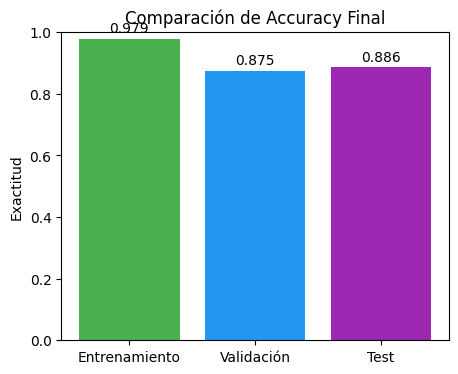

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1️⃣ Curvas de entrenamiento
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución del Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución del Loss')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# 2️⃣ Matriz de confusión y reporte de clasificación
print("📋 Reporte de clasificación (validación):")

# Obtener etiquetas verdaderas y predichas
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = (model.predict(val_ds) > 0.5).astype("int32")

print(classification_report(y_true, y_pred, target_names=['Normal', 'Neumonía']))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Neumonía'],
            yticklabels=['Normal', 'Neumonía'])
plt.title("Matriz de confusión (validación)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# 3️⃣ Comparación de accuracy final
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

# Evaluar test si aún no se hizo
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

plt.figure(figsize=(5,4))
plt.bar(['Entrenamiento', 'Validación', 'Test'], [train_acc, val_acc, test_acc], color=['#4CAF50','#2196F3','#9C27B0'])
plt.ylim(0,1)
plt.title('Comparación de Accuracy Final')
plt.ylabel('Exactitud')
for i, acc in enumerate([train_acc, val_acc, test_acc]):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10)
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step


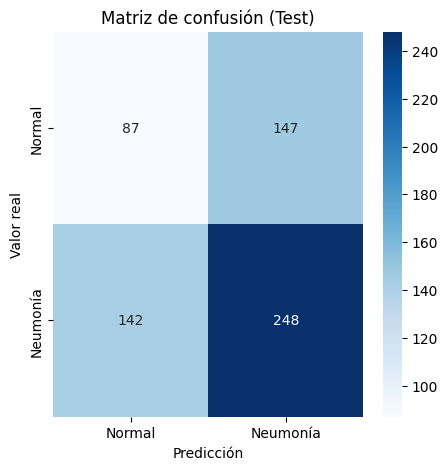

In [ ]:
# Matriz de confusión (Test):
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = (model.predict(test_ds) > 0.5).astype("int32")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Neumonía'],
            yticklabels=['Normal', 'Neumonía'])
plt.title("Matriz de confusión (Test)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()
